# Group 8 Capstone Project (HemoBridge)

## Steps
1. Import ncessary libraries, load datasets, clean the data, EDA
2. Build the intelligent donor matching system.
3. Donor availability and blood-collection predictions.
4. Build a suspicious activity detection model.
5. Design notification-routing optimization logic.
6. Test all models.

## 1. Import ncessary libraries, load datasets, clean the data, EDA

In [1]:
import pandas as pd
import numpy as np

#ignore warnings
import warnings 
warnings.filterwarnings('ignore')

#data processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#classification models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

#model evaluation
from sklearn.metrics import classification_report, roc_auc_score, precision_score

In [2]:
donors = pd.read_csv('donor.csv')
hospitals = pd.read_csv('Hospital.csv')
donors.head()

,donor_id,age,gender,blood_group,rhesus_factor,state,lga,availability,health_status,last_donation_date,eligible_to_donate
0,D100000,56,Male,A,-,Ogun,Mushin,Unavailable,Healthy,2025-03-27,No
1,D100001,46,Male,A,+,Rivers,Surulere,Unavailable,Healthy,2025-05-29,No
2,D100002,32,Female,O,+,Oyo,Eti-Osa,Available,Healthy,2026-01-07,Yes
3,D100003,25,Female,A,+,Rivers,Lekki,Unavailable,Healthy,2026-04-25,No
4,D100004,38,Male,B,-,Ogun,Ikeja,Available,Healthy,2025-05-31,Yes


In [3]:
hospitals.head()

,hospital_id,hospital_name,ownership_type,hospital_type,lga,address,total_beds,emergency_level,latitude,longitude,...,o+,o-,number_of_doctors,number_of_nurses,year_established,operating_status,hmo_accepted,emergency_service,remarks,state
0,HSP0001,Lagoon Medical Clinic,Private,Specialist,Apapa,"11 Wharf Road, Apapa, Lagos",NaN,NaN,6.640370,3.022458,...,0,0,6,41,2022,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN
1,HSP0002,Royal Health Medical Centre,Private,Maternity,Agege,"136 Iju Road, Agege, Lagos",NaN,NaN,6.426414,3.446246,...,0,0,57,179,2021,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN
2,HSP0003,Prime Care Clinic,Private,Multi-specialist,Alimosho,"1 Egbeda Road, Alimosho, Lagos",NaN,NaN,6.576825,3.346292,...,166,24,65,15,1998,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN
3,HSP0004,Life Integrated Health Centre,Private,Multi-specialist,Ifako-Ijaiye,"19 Iju Road, Ifako-Ijaiye, Lagos",NaN,NaN,6.561733,3.083357,...,111,9,22,94,1995,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN
4,HSP0005,Pearl Specialist Hospital,Private,Maternity,Ajeromi-Ifelodun,"73 Kirikiri Road, Ajeromi-Ifelodun, Lagos",NaN,NaN,6.477993,3.541460,...,0,0,78,17,2007,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN


In [4]:
donors.info

<bound method DataFrame.info of     donor_id  age  gender blood_group rhesus_factor   state       lga  \
0    D100000   56    Male           A             -    Ogun    Mushin   
1    D100001   46    Male           A             +  Rivers  Surulere   
2    D100002   32  Female           O             +     Oyo   Eti-Osa   
3    D100003   25  Female           A             +  Rivers     Lekki   
4    D100004   38    Male           B             -    Ogun     Ikeja   
..       ...  ...     ...         ...           ...     ...       ...   
995  D100995   41  Female           A             +   Abuja    Mushin   
996  D100996   32    Male           O             -  Rivers    Mushin   
997  D100997   46  Female           A             +   Lagos     Lekki   
998  D100998   25    Male           O             +     Oyo    Kosofe   
999  D100999   22  Female           A             +     Oyo  Surulere   

    availability health_status last_donation_date eligible_to_donate  
0    Unavailable    

In [5]:
hospitals.info

<bound method DataFrame.info of     hospital_id                         hospital_name ownership_type  \
0       HSP0001                 Lagoon Medical Clinic        Private   
1       HSP0002           Royal Health Medical Centre        Private   
2       HSP0003                     Prime Care Clinic        Private   
3       HSP0004         Life Integrated Health Centre        Private   
4       HSP0005             Pearl Specialist Hospital        Private   
..          ...                                   ...            ...   
995     HSP0996                  Bridge Health Clinic        Private   
996     HSP0997  Royal Specialist Specialist Hospital        Private   
997     HSP0998                   Blue Medical Clinic        Private   
998     HSP0999      Cedar Family Specialist Hospital        Private   
999     HSP1000  Grace Diagnostic Specialist Hospital        Private   

        hospital_type               lga  \
0          Specialist             Apapa   
1           Mater

In [6]:
hospitals.describe

<bound method NDFrame.describe of     hospital_id                         hospital_name ownership_type  \
0       HSP0001                 Lagoon Medical Clinic        Private   
1       HSP0002           Royal Health Medical Centre        Private   
2       HSP0003                     Prime Care Clinic        Private   
3       HSP0004         Life Integrated Health Centre        Private   
4       HSP0005             Pearl Specialist Hospital        Private   
..          ...                                   ...            ...   
995     HSP0996                  Bridge Health Clinic        Private   
996     HSP0997  Royal Specialist Specialist Hospital        Private   
997     HSP0998                   Blue Medical Clinic        Private   
998     HSP0999      Cedar Family Specialist Hospital        Private   
999     HSP1000  Grace Diagnostic Specialist Hospital        Private   

        hospital_type               lga  \
0          Specialist             Apapa   
1           Mat

In [7]:
donors.columns

Index(['donor_id', 'age', 'gender', 'blood_group', 'rhesus_factor', 'state',
       'lga', 'availability', 'health_status', 'last_donation_date',
       'eligible_to_donate'],
      dtype='str')

In [8]:
hospitals.columns

Index(['hospital_id', 'hospital_name', 'ownership_type', 'hospital_type',
       'lga', 'address', 'total_beds', 'emergency_level', 'latitude',
       'longitude', 'blood_donation_centre', 'average_monthly_donors',
       'monthly_blood_units_collected', 'annual_blood_units_collected', 'a+',
       'a-', 'b+', 'b-', 'ab+', 'ab-', 'o+', 'o-', 'number_of_doctors',
       'number_of_nurses', 'year_established', 'operating_status',
       'hmo_accepted', 'emergency_service', 'remarks', 'state'],
      dtype='str')

In [9]:
donors.isnull().sum()

donor_id              0
age                   0
gender                0
blood_group           0
rhesus_factor         0
state                 0
lga                   0
availability          0
health_status         0
last_donation_date    0
eligible_to_donate    0
dtype: int64

In [10]:
hospitals.isnull().sum()

hospital_id                         0
hospital_name                       0
ownership_type                      0
hospital_type                       0
lga                                 0
address                             0
total_beds                       1000
emergency_level                  1000
latitude                            0
longitude                           0
blood_donation_centre               0
average_monthly_donors              0
monthly_blood_units_collected       0
annual_blood_units_collected        0
a+                                  0
a-                                  0
b+                                  0
b-                                  0
ab+                                 0
ab-                                 0
o+                                  0
o-                                  0
number_of_doctors                   0
number_of_nurses                    0
year_established                    0
operating_status                    0
hmo_accepted

### Handling missing values

In [11]:
cols_to_drop = ['total_beds', 'emergency_level', 'state']
hospitals = hospitals.drop(columns=cols_to_drop)

In [12]:
hospitals.isnull().sum()

hospital_id                      0
hospital_name                    0
ownership_type                   0
hospital_type                    0
lga                              0
address                          0
latitude                         0
longitude                        0
blood_donation_centre            0
average_monthly_donors           0
monthly_blood_units_collected    0
annual_blood_units_collected     0
a+                               0
a-                               0
b+                               0
b-                               0
ab+                              0
ab-                              0
o+                               0
o-                               0
number_of_doctors                0
number_of_nurses                 0
year_established                 0
operating_status                 0
hmo_accepted                     0
emergency_service                0
remarks                          0
dtype: int64

In [13]:
hospitals.dtypes

hospital_id                          str
hospital_name                        str
ownership_type                       str
hospital_type                        str
lga                                  str
address                              str
latitude                         float64
longitude                        float64
blood_donation_centre                str
average_monthly_donors             int64
monthly_blood_units_collected      int64
annual_blood_units_collected       int64
a+                                 int64
a-                                 int64
b+                                 int64
b-                                 int64
ab+                                int64
ab-                                int64
o+                                 int64
o-                                 int64
number_of_doctors                  int64
number_of_nurses                   int64
year_established                   int64
operating_status                     str
hmo_accepted    

In [14]:
 # 1. Convert Yes/No flags to 1/0
flag_cols = ['blood_donation_centre', 'hmo_accepted', 'emergency_service']
for col in flag_cols:
    hospitals[col] = hospitals[col].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})

# 2. Convert to category for memory + modeling
cat_cols = ['ownership_type', 'hospital_type', 
            'lga', 'operating_status', 'remarks']
hospitals[cat_cols] = hospitals[cat_cols].astype('category')

In [15]:
# 3. Verify
hospitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   hospital_id                    1000 non-null   str     
 1   hospital_name                  1000 non-null   str     
 2   ownership_type                 1000 non-null   category
 3   hospital_type                  1000 non-null   category
 4   lga                            1000 non-null   category
 5   address                        1000 non-null   str     
 6   latitude                       1000 non-null   float64 
 7   longitude                      1000 non-null   float64 
 8   blood_donation_centre          1000 non-null   int64   
 9   average_monthly_donors         1000 non-null   int64   
 10  monthly_blood_units_collected  1000 non-null   int64   
 11  annual_blood_units_collected   1000 non-null   int64   
 12  a+                             1000 non-null  

In [16]:
hospitals.isnull().sum()

hospital_id                         0
hospital_name                       0
ownership_type                      0
hospital_type                       0
lga                                 0
address                             0
latitude                            0
longitude                           0
blood_donation_centre               0
average_monthly_donors              0
monthly_blood_units_collected       0
annual_blood_units_collected        0
a+                                  0
a-                                  0
b+                                  0
b-                                  0
ab+                                 0
ab-                                 0
o+                                  0
o-                                  0
number_of_doctors                   0
number_of_nurses                    0
year_established                    0
operating_status                    0
hmo_accepted                        0
emergency_service                1000
remarks     

In [17]:
hospitals = hospitals.drop(columns=['emergency_service', 'remarks'])

hospitals.isnull().sum()

hospital_id                      0
hospital_name                    0
ownership_type                   0
hospital_type                    0
lga                              0
address                          0
latitude                         0
longitude                        0
blood_donation_centre            0
average_monthly_donors           0
monthly_blood_units_collected    0
annual_blood_units_collected     0
a+                               0
a-                               0
b+                               0
b-                               0
ab+                              0
ab-                              0
o+                               0
o-                               0
number_of_doctors                0
number_of_nurses                 0
year_established                 0
operating_status                 0
hmo_accepted                     0
dtype: int64

In [18]:
hospitals.shape

(1000, 25)

In [19]:
# 1. Get donor counts + blood group supply by LGA
donors = donors.drop(columns=['state'])
donors.columns

Index(['donor_id', 'age', 'gender', 'blood_group', 'rhesus_factor', 'lga',
       'availability', 'health_status', 'last_donation_date',
       'eligible_to_donate'],
      dtype='str')

In [20]:
donors.dtypes

donor_id                str
age                   int64
gender                  str
blood_group             str
rhesus_factor           str
lga                     str
availability            str
health_status           str
last_donation_date      str
eligible_to_donate      str
dtype: object

In [21]:
# 1. Convert date
donors['last_donation_date'] = pd.to_datetime(donors['last_donation_date'], errors='coerce')

# 2. Convert to category 
cat_cols = ['gender', 'blood_group', 'rhesus_factor', 'lga', 'availability', 'health_status', 'eligible_to_donate']
donors[cat_cols] = donors[cat_cols].astype('category')

donors.dtypes

donor_id                         str
age                            int64
gender                      category
blood_group                 category
rhesus_factor               category
lga                         category
availability                category
health_status               category
last_donation_date    datetime64[us]
eligible_to_donate          category
dtype: object

In [22]:
donors.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   donor_id            1000 non-null   str           
 1   age                 1000 non-null   int64         
 2   gender              1000 non-null   category      
 3   blood_group         1000 non-null   category      
 4   rhesus_factor       1000 non-null   category      
 5   lga                 1000 non-null   category      
 6   availability        1000 non-null   category      
 7   health_status       1000 non-null   category      
 8   last_donation_date  1000 non-null   datetime64[us]
 9   eligible_to_donate  1000 non-null   category      
dtypes: category(7), datetime64[us](1), int64(1), str(1)
memory usage: 30.7 KB


In [23]:
donors.shape

(1000, 10)

### Exploratory Data Analysis

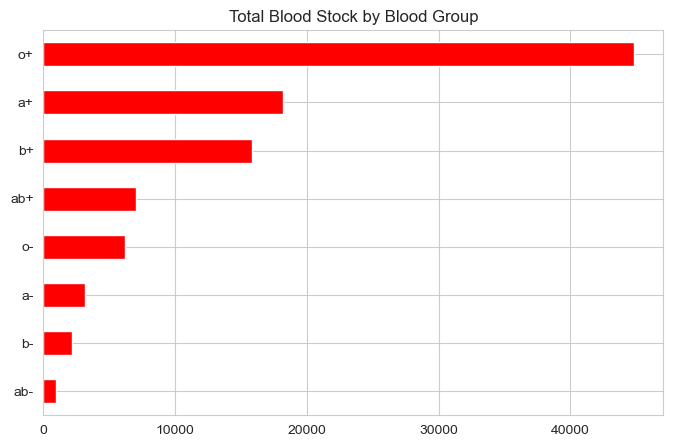

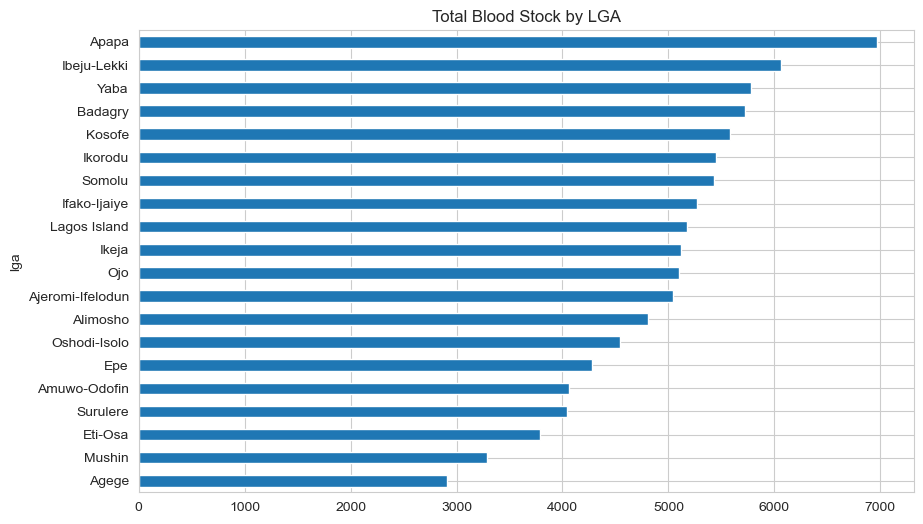

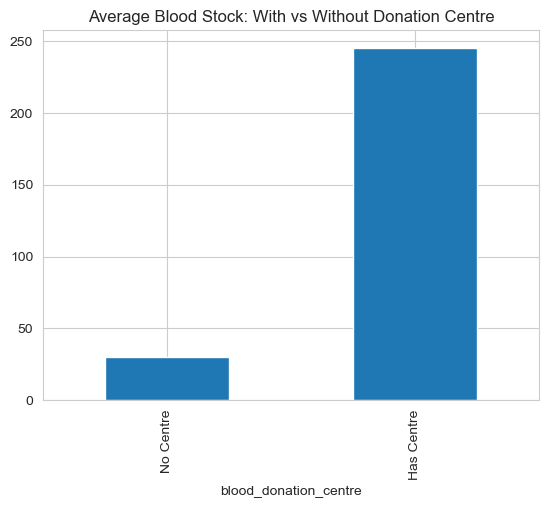

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# 1. Blood stock by blood group - see what's most scarce
blood_cols = ['a+', 'a-', 'b+', 'b-', 'ab+', 'ab-', 'o+', 'o-']
blood_totals = hospitals[blood_cols].sum().sort_values()
blood_totals.plot(kind='barh', figsize=(8,5), color='red')
plt.title('Total Blood Stock by Blood Group')
plt.show()

# 2. Total blood stock by LGA - see which areas are underserved
hospitals['total_blood_stock'] = hospitals[blood_cols].sum(axis=1)
hospitals.groupby('lga')['total_blood_stock'].sum().sort_values().plot(kind='barh', figsize=(10,6))
plt.title('Total Blood Stock by LGA')
plt.show()

# 3. Do donation centres help?
hospitals.groupby('blood_donation_centre')['total_blood_stock'].mean().plot(kind='bar')
plt.title('Average Blood Stock: With vs Without Donation Centre')
plt.xticks([0,1], ['No Centre', 'Has Centre'])
plt.show()

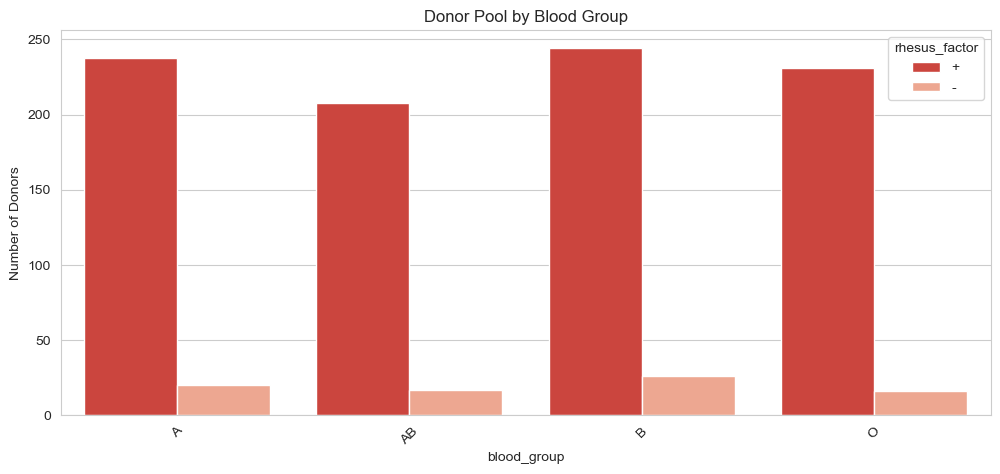

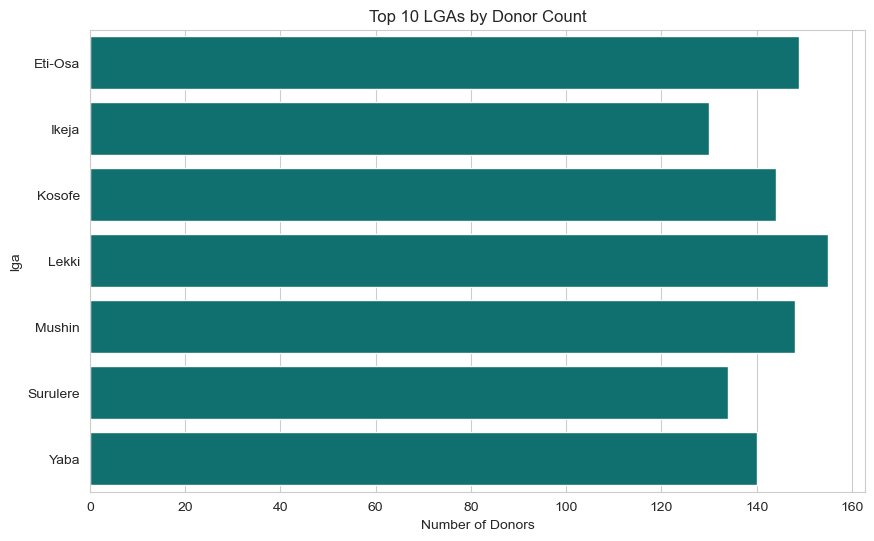

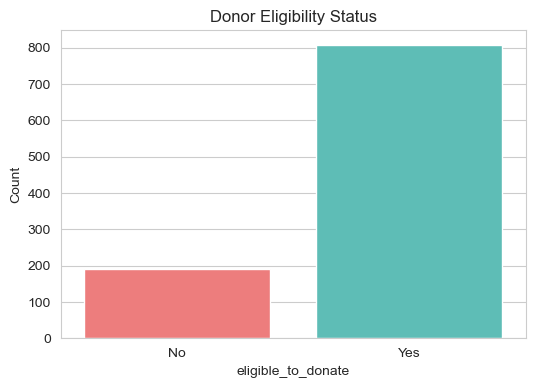

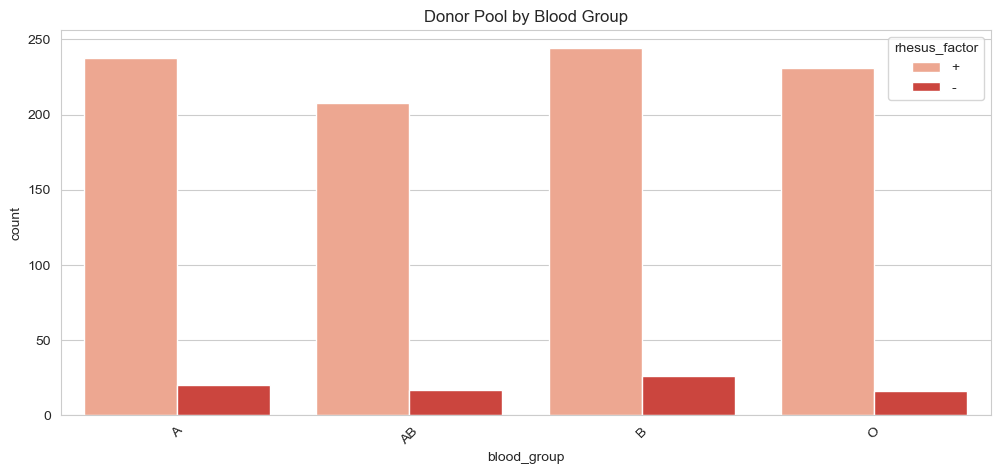

In [25]:
# 1. Blood Supply Base: Donors by Blood Group + Rhesus
plt.figure(figsize=(12,5))
sns.countplot(data=donors, x='blood_group', hue='rhesus_factor', palette='Reds_r')
plt.title('Donor Pool by Blood Group')
plt.xticks(rotation=45)
plt.ylabel('Number of Donors')
plt.show()

# 2. Geography: Top 10 LGAs by Donor Count
plt.figure(figsize=(10,6))
top_lga = donors['lga'].value_counts().head(10)
sns.barplot(x=top_lga.values, y=top_lga.index, color='#008080') # teal hex code
plt.title('Top 10 LGAs by Donor Count')
plt.xlabel('Number of Donors')
plt.show()

# 3. Eligibility Bottleneck - fixed colors
plt.figure(figsize=(6,4))
sns.countplot(data=donors, x='eligible_to_donate', palette=['#FF6B6B','#4ECDC4'])
plt.title('Donor Eligibility Status')
plt.ylabel('Count')
plt.show()

# Blood Group - use built-in palette
plt.figure(figsize=(12,5))
sns.countplot(data=donors, x='blood_group', hue='rhesus_factor', palette='Reds')
plt.title('Donor Pool by Blood Group')
plt.xticks(rotation=45)
plt.show()

In [26]:
# 1. Reshape hospital data to long format
blood_cols = ['a+', 'a-', 'b+', 'b-', 'ab+', 'ab-', 'o+', 'o-']
hospital_blood = hospitals.melt(id_vars=['lga'], value_vars=blood_cols, 
                                var_name='blood_group', value_name='hospital_stock')
hospital_blood_sum = hospital_blood.groupby(['lga', 'blood_group'])['hospital_stock'].sum().reset_index()

# 2. Get donor count by LGA + blood_group
donor_summary = donors.groupby(['lga', 'blood_group']).size().reset_index(name='donor_count')

# 3. MERGE
supply_demand = pd.merge(donor_summary, hospital_blood_sum, on=['lga', 'blood_group'], how='outer').fillna(0)
supply_demand['stock_gap'] = supply_demand['hospital_stock'] - supply_demand['donor_count']

# 4. Find CRITICAL shortages
critical = supply_demand.sort_values('stock_gap').head(10)
critical

,lga,blood_group,donor_count,hospital_stock,stock_gap
106,Kosofe,B,47.0,0.0,-47.0
128,Mushin,A,45.0,0.0,-45.0
167,Surulere,O,42.0,0.0,-42.0
58,Eti-Osa,B,41.0,0.0,-41.0
127,Lekki,O,41.0,0.0,-41.0
126,Lekki,B,41.0,0.0,-41.0
130,Mushin,B,40.0,0.0,-40.0
176,Yaba,A,40.0,0.0,-40.0
84,Ikeja,A,39.0,0.0,-39.0
107,Kosofe,O,39.0,0.0,-39.0


## 2.  Building the intelligent donor matching System.

In [27]:
# 1. Creating blood compatibility rules.

compatibility = {
    "O-":["O-", "O+", "A-", "A+", "B-", "B+", "AB-", "AB+"],
    "O+":["O+", "A+", "B+", "AB+"],
    "A-":["A-", "A+", "AB-", "AB+"],
    "A+":["A+", "AB+"],
    "B-":["B-", "B+", "AB-", "AB+"],
    "B+":["B+", "AB+"],
    "AB-":["AB-", "AB+"],
    "AB+":["AB+"]
    
}

In [28]:
# 2.  Filtering compatible donors.

requested = "O+"
eligible = donors[
    donors["blood_group"].isin(
        compatibility[requested]
    )
]

In [29]:
# 3. Removing unavailable donors.

eligible = eligible[
    eligible["eligible_to_donate"]=="Yes"
    ]

In [30]:
donors.head()

,donor_id,age,gender,blood_group,rhesus_factor,lga,availability,health_status,last_donation_date,eligible_to_donate
0,D100000,56,Male,A,-,Mushin,Unavailable,Healthy,2025-03-27,No
1,D100001,46,Male,A,+,Surulere,Unavailable,Healthy,2025-05-29,No
2,D100002,32,Female,O,+,Eti-Osa,Available,Healthy,2026-01-07,Yes
3,D100003,25,Female,A,+,Lekki,Unavailable,Healthy,2026-04-25,No
4,D100004,38,Male,B,-,Ikeja,Available,Healthy,2025-05-31,Yes


In [31]:
# 4. Converting 'available' to numbers
donors["AvailabilityScore"] = donors["eligible_to_donate"].map({
    "Yes": 1,
    "No": 0
}).astype(int)


In [32]:
# 5. Normalizing the distance
hospital_lga = "Mushin"

donors["LocationScore"] = donors["lga"].apply(
    lambda x: 1 if x == hospital_lga else 0
)

#Same lga = 1
#Different lga = 0

In [33]:
# 6. Normalizing previous donations

donors["last_donation_date"] = pd.to_datetime(donors["last_donation_date"])

#get today's date
today = pd.Timestamp.today()

donors["DaysSinceDonation"] = (
    today - donors["last_donation_date"]
).dt.days

In [34]:
donors.head()

,donor_id,age,gender,blood_group,rhesus_factor,lga,availability,health_status,last_donation_date,eligible_to_donate,AvailabilityScore,LocationScore,DaysSinceDonation
0,D100000,56,Male,A,-,Mushin,Unavailable,Healthy,2025-03-27,No,0,1,507
1,D100001,46,Male,A,+,Surulere,Unavailable,Healthy,2025-05-29,No,0,0,444
2,D100002,32,Female,O,+,Eti-Osa,Available,Healthy,2026-01-07,Yes,1,0,221
3,D100003,25,Female,A,+,Lekki,Unavailable,Healthy,2026-04-25,No,0,0,113
4,D100004,38,Male,B,-,Ikeja,Available,Healthy,2025-05-31,Yes,1,0,442


In [35]:
# 7.reating an eligibility score
#donors wait 56days before next donation

donors["DonationEligibility"] = donors["DaysSinceDonation"].apply(
    lambda x: 1 if x >= 56 else 0
)

In [36]:
# 8. Calculating the final score for DonationEligibility

donors["FinalScore"] = (
    donors["LocationScore"] * 0.5 +
    donors["AvailabilityScore"] * 0.3 +
    donors["DonationEligibility"] * 0.2
)

In [37]:
# 9. Ranking the donors based on their scores

ranked_donors = donors.sort_values(
    by="FinalScore",
    ascending=False
)

ranked_donors.head(10)

,donor_id,age,gender,blood_group,rhesus_factor,lga,availability,health_status,last_donation_date,eligible_to_donate,AvailabilityScore,LocationScore,DaysSinceDonation,DonationEligibility,FinalScore
794,D100794,45,Female,B,+,Mushin,Available,Healthy,2025-01-19,Yes,1,1,574,1,1.0
994,D100994,53,Male,A,-,Mushin,Available,Healthy,2025-01-11,Yes,1,1,582,1,1.0
995,D100995,41,Female,A,+,Mushin,Available,Healthy,2025-07-06,Yes,1,1,406,1,1.0
996,D100996,32,Male,O,-,Mushin,Available,Healthy,2025-01-15,Yes,1,1,578,1,1.0
749,D100749,28,Male,B,+,Mushin,Available,Healthy,2026-03-02,Yes,1,1,167,1,1.0
24,D100024,39,Male,B,+,Mushin,Available,Healthy,2026-04-25,Yes,1,1,113,1,1.0
26,D100026,44,Female,A,+,Mushin,Available,Healthy,2025-06-05,Yes,1,1,437,1,1.0
33,D100033,24,Female,AB,+,Mushin,Available,Healthy,2025-09-19,Yes,1,1,331,1,1.0
776,D100776,51,Male,AB,+,Mushin,Available,Healthy,2026-03-26,Yes,1,1,143,1,1.0
966,D100966,23,Female,A,+,Mushin,Available,Healthy,2026-04-09,Yes,1,1,129,1,1.0


In [38]:
# 10. Selecting the top 5 donors.

top_donors = ranked_donors.head(5)
top_donors

,donor_id,age,gender,blood_group,rhesus_factor,lga,availability,health_status,last_donation_date,eligible_to_donate,AvailabilityScore,LocationScore,DaysSinceDonation,DonationEligibility,FinalScore
794,D100794,45,Female,B,+,Mushin,Available,Healthy,2025-01-19,Yes,1,1,574,1,1.0
994,D100994,53,Male,A,-,Mushin,Available,Healthy,2025-01-11,Yes,1,1,582,1,1.0
995,D100995,41,Female,A,+,Mushin,Available,Healthy,2025-07-06,Yes,1,1,406,1,1.0
996,D100996,32,Male,O,-,Mushin,Available,Healthy,2025-01-15,Yes,1,1,578,1,1.0
749,D100749,28,Male,B,+,Mushin,Available,Healthy,2026-03-02,Yes,1,1,167,1,1.0


In [39]:
print(donors.columns.tolist())

['donor_id', 'age', 'gender', 'blood_group', 'rhesus_factor', 'lga', 'availability', 'health_status', 'last_donation_date', 'eligible_to_donate', 'AvailabilityScore', 'LocationScore', 'DaysSinceDonation', 'DonationEligibility', 'FinalScore']


In [40]:
hospitals.columns

Index(['hospital_id', 'hospital_name', 'ownership_type', 'hospital_type',
       'lga', 'address', 'latitude', 'longitude', 'blood_donation_centre',
       'average_monthly_donors', 'monthly_blood_units_collected',
       'annual_blood_units_collected', 'a+', 'a-', 'b+', 'b-', 'ab+', 'ab-',
       'o+', 'o-', 'number_of_doctors', 'number_of_nurses', 'year_established',
       'operating_status', 'hmo_accepted', 'total_blood_stock'],
      dtype='str')

## 3a. Building Donor Availability Prediction.

In [41]:
donors["eligible_to_donate"].value_counts()

eligible_to_donate
Yes    808
No     192
Name: count, dtype: int64

In [42]:
donors["availability"].value_counts()

availability
Available      808
Unavailable    192
Name: count, dtype: int64

In [43]:
donors["health_status"].value_counts()

health_status
Healthy    1000
Name: count, dtype: int64

In [44]:
# 1. Define the features and target
availability_features = [
    'age',
    'DaysSinceDonation',
    'gender',
    'blood_group',
    'rhesus_factor',
    'lga'
]

X = donors[availability_features]
y = donors['availability']

In [45]:
# 2. Converting the target to numbers
y = y.map({
     "Available": 1,
     "Unavailable": 0
 })

In [46]:
#Confirming change
y.value_counts()

availability
1    808
0    192
Name: count, dtype: int64

In [47]:
# 3. Splitting the donor data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
# 4. Identifying numerical and categorical features

numeric_features = [
    "age",
    "DaysSinceDonation"
]

categorical_features = [
    "gender",
    "blood_group",
    "rhesus_factor",
    "lga"
]

In [49]:
#Import necessary libraries
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

#### Creating numerical and categorical preprocessing
because the dataset contains different types of info, and the model cant work directly with all of them

In [113]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [114]:
#combining them
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [115]:
# 5. Creating the Random forest model

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [116]:
# 6. Combining the preprocessing with the model

availability_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf)
])

In [117]:
# 7. Train the model
availability_model.fit(X_train, y_train)

ValueError: A given column is not a column of the dataframe

In [ ]:
# Make predictions
availability_pred = availability_model.predict(X_test)

availability_pred
#NOTE: 1=available, 0=unavailable

In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": availability_pred
})

results.head(10)

In [ ]:
#Evaluating the model

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, availability_pred))

print("\nClassification Report:")
print(classification_report(y_test, availability_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, availability_pred))

#### Summary of the above report
The model achieved 76.5% accuracy, meaning it correctly predicted donor availability for about 77% of the test donors, but it performed poorly at identifying unavailable donors (only 3% recall for class 0), so the model needs improvement.

### Model Comparism

We tried using the Logistic Regression model to compare the reults but the Random Forest performed better, achieving 77% accuracy, while Logistic Regression achieved 52.5%. This means Random Forest was more effective at predicting donor availability in our dataset so we cleared out the logistic Regressor to avoid confusion and crowding. Therefore, Random Forest is the preferred model for Hemobridge at this stage.

## 3b. Building Blood collection Prediction Model.

In [118]:
hospitals = pd.read_csv('Hospital.csv')

hospitals.head()

,hospital_id,hospital_name,ownership_type,hospital_type,lga,address,total_beds,emergency_level,latitude,longitude,...,o+,o-,number_of_doctors,number_of_nurses,year_established,operating_status,hmo_accepted,emergency_service,remarks,state
0,HSP0001,Lagoon Medical Clinic,Private,Specialist,Apapa,"11 Wharf Road, Apapa, Lagos",NaN,NaN,6.640370,3.022458,...,0,0,6,41,2022,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN
1,HSP0002,Royal Health Medical Centre,Private,Maternity,Agege,"136 Iju Road, Agege, Lagos",NaN,NaN,6.426414,3.446246,...,0,0,57,179,2021,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN
2,HSP0003,Prime Care Clinic,Private,Multi-specialist,Alimosho,"1 Egbeda Road, Alimosho, Lagos",NaN,NaN,6.576825,3.346292,...,166,24,65,15,1998,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN
3,HSP0004,Life Integrated Health Centre,Private,Multi-specialist,Ifako-Ijaiye,"19 Iju Road, Ifako-Ijaiye, Lagos",NaN,NaN,6.561733,3.083357,...,111,9,22,94,1995,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN
4,HSP0005,Pearl Specialist Hospital,Private,Maternity,Ajeromi-Ifelodun,"73 Kirikiri Road, Ajeromi-Ifelodun, Lagos",NaN,NaN,6.477993,3.541460,...,0,0,78,17,2007,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN


In [119]:
hospitals.columns

Index(['hospital_id', 'hospital_name', 'ownership_type', 'hospital_type',
       'lga', 'address', 'total_beds', 'emergency_level', 'latitude',
       'longitude', 'blood_donation_centre', 'average_monthly_donors',
       'monthly_blood_units_collected', 'annual_blood_units_collected', 'a+',
       'a-', 'b+', 'b-', 'ab+', 'ab-', 'o+', 'o-', 'number_of_doctors',
       'number_of_nurses', 'year_established', 'operating_status',
       'hmo_accepted', 'emergency_service', 'remarks', 'state'],
      dtype='str')

In [120]:
hospitals.isnull().sum()

hospital_id                         0
hospital_name                       0
ownership_type                      0
hospital_type                       0
lga                                 0
address                             0
total_beds                       1000
emergency_level                  1000
latitude                            0
longitude                           0
blood_donation_centre               0
average_monthly_donors              0
monthly_blood_units_collected       0
annual_blood_units_collected        0
a+                                  0
a-                                  0
b+                                  0
b-                                  0
ab+                                 0
ab-                                 0
o+                                  0
o-                                  0
number_of_doctors                   0
number_of_nurses                    0
year_established                    0
operating_status                    0
hmo_accepted

In [121]:
hospitals = hospitals.drop(columns=["total_beds", "emergency_level", "state"])

In [122]:
# 1. Understanding the blood group columns

hospitals[["a+", "a-", "b+", "b-", "ab+", "ab-", "o+", "o-"]].head()

,a+,a-,b+,b-,ab+,ab-,o+,o-
0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,75,1,16,6,7,5,166,24
3,52,1,59,4,25,1,111,9
4,0,0,0,0,0,0,0,0


In [123]:
hospitals[["a+", "a-", "b+", "b-", "ab+", "ab-", "o+", "o-"]].describe()

,a+,a-,b+,b-,ab+,ab-,o+,o-
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,18.168000,3.192000,15.824000,2.13900,7.031000,0.995000,44.820000,6.226000
std,25.679899,4.784561,22.541321,3.13712,9.871651,1.614801,64.130104,9.370311
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,6.000000,31.000000,5.00000,14.000000,2.000000,92.000000,12.000000
max,80.000000,15.000000,70.000000,10.00000,30.000000,5.000000,200.000000,30.000000


In [124]:
blood_columns = ["a+", "a-", "b+", "b-", "ab+", "ab-", "o+", "o-"]

hospitals["total_blood_groups"] = hospitals[blood_columns].sum(axis=1)

hospitals[[
    "monthly_blood_units_collected",
    "total_blood_groups"
]].head(20)

,monthly_blood_units_collected,total_blood_groups
0,0,0
1,0,0
2,30,300
3,0,262
4,0,0
5,161,234
6,31,237
7,0,0
8,120,201
9,0,0


In [125]:
hospitals["difference"] = (
    hospitals["monthly_blood_units_collected"]
    - hospitals["total_blood_groups"]
)

hospitals[[
    "monthly_blood_units_collected",
    "total_blood_groups",
    "difference"
]].head(20)

,monthly_blood_units_collected,total_blood_groups,difference
0,0,0,0
1,0,0,0
2,30,300,-270
3,0,262,-262
4,0,0,0
5,161,234,-73
6,31,237,-206
7,0,0,0
8,120,201,-81
9,0,0,0


In [126]:
#Then to calculate the difference
hospitals[[
    "monthly_blood_units_collected",
    "total_blood_groups"
]].corr()

,monthly_blood_units_collected,total_blood_groups
monthly_blood_units_collected,1.000000,0.647973
total_blood_groups,0.647973,1.000000


In [127]:
# Splitting and training the dataset

y = hospitals["monthly_blood_units_collected"]

#we are leaving out "annualbloodunitscollected" because it is closely related to "monthlybloodunitscollected" to avoid data leakage
features = [
    "average_monthly_donors",
    "a+",
    "a-",
    "b+",
    "b-",
    "ab+",
    "ab-",
    "o+",
    "o-",
    "number_of_doctors",
    "number_of_nurses",
    "year_established"
]

X = hospitals[features]
y = hospitals["monthly_blood_units_collected"]

In [128]:
#Checking X and y before training
X.head()

,average_monthly_donors,a+,a-,b+,b-,ab+,ab-,o+,o-,number_of_doctors,number_of_nurses,year_established
0,0,0,0,0,0,0,0,0,0,6,41,2022
1,0,0,0,0,0,0,0,0,0,57,179,2021
2,31,75,1,16,6,7,5,166,24,65,15,1998
3,0,52,1,59,4,25,1,111,9,22,94,1995
4,0,0,0,0,0,0,0,0,0,78,17,2007


In [129]:
y.head()

0     0
1     0
2    30
3     0
4     0
Name: monthly_blood_units_collected, dtype: int64

In [130]:
X.shape, y.shape

((1000, 12), (1000,))

In [131]:
#Checking for missing values before training
X.isnull().sum()

average_monthly_donors    0
a+                        0
a-                        0
b+                        0
b-                        0
ab+                       0
ab-                       0
o+                        0
o-                        0
number_of_doctors         0
number_of_nurses          0
year_established          0
dtype: int64

In [132]:
# 2. Training the model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [133]:
from sklearn.ensemble import RandomForestRegressor
blood_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [134]:
blood_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [135]:
# 3. Making predictions

y_pred = blood_model.predict(X_test)
y_pred[:10]

array([289.99,   0.  , 236.99,   0.  , 116.52,  41.49,   0.  ,  86.16,
       149.7 ,   0.  ])

In [136]:
# 4. Evaluating the model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

#RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

#R2
r2 = r2_score(y_test, y_pred)
print("R²:", r2)



MAE: 7.754250000000001
RMSE: 20.28383357504197
R²: 0.9700155634204852


#### Result Summary
The Random Forest model achieved an R² score of 0.97, meaning it explains about 97% of the variation in monthly blood units collected. The MAE of 7.75 means the model’s predictions were off by about 8 blood units on average, while the RMSE of 20.28 indicates some larger prediction errors. Overall, the model performed very well and shows strong potential for predicting monthly blood collection.

In [137]:
# 5. Checking Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": blood_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,average_monthly_donors,0.970616
3,b+,0.003371
9,number_of_doctors,0.003206
11,year_established,0.003078
10,number_of_nurses,0.003069
5,ab+,0.002982
7,o+,0.002902
8,o-,0.002880
1,a+,0.002462
4,b-,0.001878


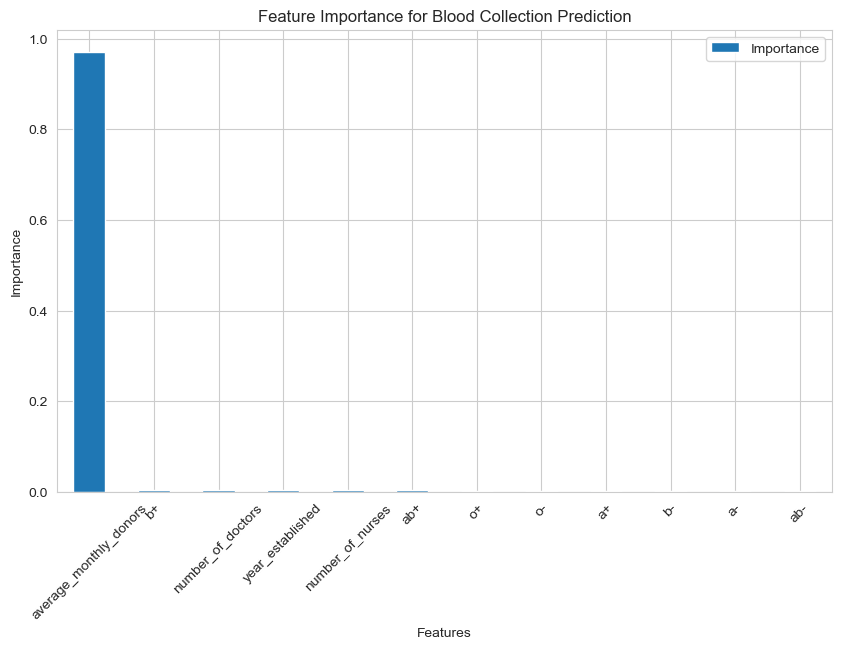

In [138]:
#Visualization

import matplotlib.pyplot as plt

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10, 6)
)

plt.title("Feature Importance for Blood Collection Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

##### This shows that average_monthly_donors is by far the most influential feature, with an importance of 97.1%

In [139]:
# 6. Comparing Actual vs Predicted values
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,299,289.99
1,0,0.00
2,251,236.99
3,0,0.00
4,95,116.52
5,34,41.49
6,0,0.00
7,92,86.16
8,156,149.70
9,0,0.00


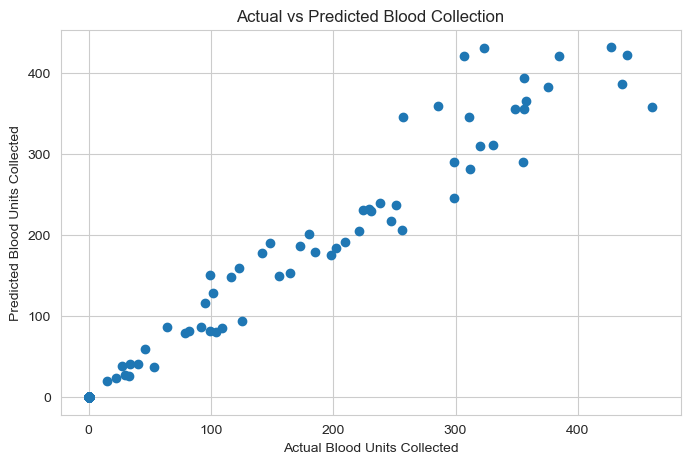

In [140]:
#Visualization

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Blood Units Collected")
plt.ylabel("Predicted Blood Units Collected")
plt.title("Actual vs Predicted Blood Collection")

plt.show()

## 4. Building Suspicious Activity Detection

In [141]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder

In [142]:
hospitals.head()

,hospital_id,hospital_name,ownership_type,hospital_type,lga,address,latitude,longitude,blood_donation_centre,average_monthly_donors,...,o-,number_of_doctors,number_of_nurses,year_established,operating_status,hmo_accepted,emergency_service,remarks,total_blood_groups,difference
0,HSP0001,Lagoon Medical Clinic,Private,Specialist,Apapa,"11 Wharf Road, Apapa, Lagos",6.640370,3.022458,No,0,...,0,6,41,2022,Active,Yes,24 Hours,Synthetic dataset for analysis,0,0
1,HSP0002,Royal Health Medical Centre,Private,Maternity,Agege,"136 Iju Road, Agege, Lagos",6.426414,3.446246,No,0,...,0,57,179,2021,Active,Yes,24 Hours,Synthetic dataset for analysis,0,0
2,HSP0003,Prime Care Clinic,Private,Multi-specialist,Alimosho,"1 Egbeda Road, Alimosho, Lagos",6.576825,3.346292,Yes,31,...,24,65,15,1998,Active,Yes,24 Hours,Synthetic dataset for analysis,300,-270
3,HSP0004,Life Integrated Health Centre,Private,Multi-specialist,Ifako-Ijaiye,"19 Iju Road, Ifako-Ijaiye, Lagos",6.561733,3.083357,No,0,...,9,22,94,1995,Active,Yes,24 Hours,Synthetic dataset for analysis,262,-262
4,HSP0005,Pearl Specialist Hospital,Private,Maternity,Ajeromi-Ifelodun,"73 Kirikiri Road, Ajeromi-Ifelodun, Lagos",6.477993,3.541460,No,0,...,0,78,17,2007,Active,Yes,24 Hours,Synthetic dataset for analysis,0,0


In [143]:
# 1. Selecting features for anomaly detection

fraud_features = [
    "average_monthly_donors",
    "monthly_blood_units_collected",
    "annual_blood_units_collected",
    "a+",
    "a-",
    "b+",
    "b-",
    "ab+",
    "ab-",
    "o+",
    "o-",
    "number_of_doctors",
    "number_of_nurses",
    "year_established"
]

In [144]:
X_fraud = hospitals[fraud_features].copy()

In [145]:
X_fraud.isnull().sum()

average_monthly_donors           0
monthly_blood_units_collected    0
annual_blood_units_collected     0
a+                               0
a-                               0
b+                               0
b-                               0
ab+                              0
ab-                              0
o+                               0
o-                               0
number_of_doctors                0
number_of_nurses                 0
year_established                 0
dtype: int64

In [146]:
# 2. Training anomaly detection model using isolation forest

model_fraud = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model_fraud.fit(X_fraud)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [147]:
# 3. Detecting suspicious records

hospitals["suspicious_activity"] = model_fraud.predict(X_fraud)

In [148]:
hospitals[[
    "hospital_id",
    "hospital_name",
    "suspicious_activity"
]].head()

#Result interpretation: 1 = Normal, -1 = Potentially suspicious.

,hospital_id,hospital_name,suspicious_activity
0,HSP0001,Lagoon Medical Clinic,1
1,HSP0002,Royal Health Medical Centre,1
2,HSP0003,Prime Care Clinic,-1
3,HSP0004,Life Integrated Health Centre,1
4,HSP0005,Pearl Specialist Hospital,1


In [149]:
# 4. Count suspicious hospitals
hospitals["suspicious_activity"].value_counts()

suspicious_activity
 1    950
-1     50
Name: count, dtype: int64

##### This means that the model identified 50 records as potentially unusual.

In [150]:
# 5. View Suspicious records and investigate

suspicious = hospitals[
    hospitals["suspicious_activity"] == -1
    ]

suspicious[[
    "hospital_id",
    "hospital_name",
    "average_monthly_donors",
    "monthly_blood_units_collected",
    "annual_blood_units_collected",
    "number_of_doctors",
    "number_of_nurses"
]]

,hospital_id,hospital_name,average_monthly_donors,monthly_blood_units_collected,annual_blood_units_collected,number_of_doctors,number_of_nurses
2,HSP0003,Prime Care Clinic,31,30,360,65,15
20,HSP0021,Mercy Diagnostic Clinic,467,359,4308,62,20
24,HSP0025,Sunrise Community Health Centre,473,467,5604,17,33
28,HSP0029,Prime Health Hospital,405,412,4944,55,129
79,HSP0080,Mercy Specialist Clinic,419,412,4944,70,162
82,HSP0083,Harmony Diagnostic Medical Centre,454,359,4308,37,173
94,HSP0095,Blue Family Medical Centre,0,0,0,31,169
123,HSP0124,Summit Community Hospital,367,367,4404,48,149
132,HSP0133,Pearl Community Health Centre,0,0,0,38,65
140,HSP0141,Lagoon Diagnostic Hospital,428,390,4680,68,184


#### Summary
The analysis identified unusual patterns in donor numbers, blood collection, and hospital staffing, including hospitals reporting zero blood activity despite having staff and facilities. These records were flagged as potential anomalies requiring further verification, not confirmed fraudulent activity.

For example: Hospitals with 0 donors and 0 blood collected — e.g. HSP0095, HSP0133, HSP0475, HSP0636, HSP0668, HSP0822. They have doctors/nurses but report no donors or blood collection, which could be legitimate but deserves verification.

In [151]:
# 6. Adding an anomaly score

hospitals["anomaly_score"] = model_fraud.decision_function(X_fraud)

hospitals.sort_values(
    "anomaly_score"
).head(10)

,hospital_id,hospital_name,ownership_type,hospital_type,lga,address,latitude,longitude,blood_donation_centre,average_monthly_donors,...,number_of_nurses,year_established,operating_status,hmo_accepted,emergency_service,remarks,total_blood_groups,difference,suspicious_activity,anomaly_score
514,HSP0515,Crown Integrated Clinic,Private,Diagnostic,Yaba,"7 Herbert Macaulay Way, Yaba, Lagos",6.433191,3.445249,Yes,495,...,56,2013,Active,Yes,24 Hours,Synthetic dataset for analysis,296,233,-1,-0.048893
24,HSP0025,Sunrise Community Health Centre,Private,Diagnostic,Ibeju-Lekki,"31 Awoyaya Road, Ibeju-Lekki, Lagos",6.668202,3.107057,Yes,473,...,33,2015,Active,No,24 Hours,Synthetic dataset for analysis,178,289,-1,-0.043363
470,HSP0471,Hope Diagnostic Hospital,Private,Multi-specialist,Oshodi-Isolo,"136 Isolo Road, Oshodi-Isolo, Lagos",6.632502,3.140502,Yes,460,...,17,2017,Active,Yes,24 Hours,Synthetic dataset for analysis,184,224,-1,-0.040187
883,HSP0884,Nova Advanced Health Centre,Private,General,Oshodi-Isolo,"59 Airport Road, Oshodi-Isolo, Lagos",6.624992,3.087110,Yes,486,...,17,2001,Active,Yes,24 Hours,Synthetic dataset for analysis,147,293,-1,-0.034989
858,HSP0859,Sterling Integrated Health Centre,Private,Diagnostic,Lagos Island,"77 Marina Road, Lagos Island, Lagos",6.596405,3.073544,Yes,439,...,196,2022,Active,Yes,24 Hours,Synthetic dataset for analysis,264,179,-1,-0.028935
432,HSP0433,Cedar Community Health Centre,Private,Multi-specialist,Somolu,"96 Bajulaiye Road, Somolu, Lagos",6.588255,3.321951,Yes,462,...,195,2005,Active,Yes,24 Hours,Synthetic dataset for analysis,166,295,-1,-0.025017
821,HSP0822,Lagoon Specialist Medical Centre,Private,Diagnostic,Amuwo-Odofin,"79 51 Road, Amuwo-Odofin, Lagos",6.609659,3.371856,No,0,...,175,2022,Active,No,24 Hours,Synthetic dataset for analysis,335,-335,-1,-0.024435
811,HSP0812,Royal Health Specialist Hospital,Private,Specialist,Somolu,"139 Pedro Road, Somolu, Lagos",6.609448,3.627564,Yes,358,...,92,1995,Active,Yes,24 Hours,Synthetic dataset for analysis,177,154,-1,-0.024266
195,HSP0196,Sterling Integrated Specialist Hospital,Private,Maternity,Somolu,"89 Bajulaiye Road, Somolu, Lagos",6.585776,3.055408,Yes,487,...,115,1999,Active,Yes,24 Hours,Synthetic dataset for analysis,147,283,-1,-0.022120
566,HSP0567,Mercy Multi-Specialist Medical Centre,Private,Specialist,Ojo,"135 Okokomaiko Road, Ojo, Lagos",6.676660,3.577294,Yes,492,...,184,2011,Active,Yes,24 Hours,Synthetic dataset for analysis,196,291,-1,-0.020081


#### The complete suspicious activity detection process

Load dataset → Select relevant features → Handle missing values → Train Isolation Forest → Detect anomalies → Count suspicious records → Inspect flagged hospitals → Generate anomaly scores → Save the model.

In [152]:
donors.columns

Index(['donor_id', 'age', 'gender', 'blood_group', 'rhesus_factor', 'lga',
       'availability', 'health_status', 'last_donation_date',
       'eligible_to_donate', 'AvailabilityScore', 'LocationScore',
       'DaysSinceDonation', 'DonationEligibility', 'FinalScore', 'full_blood'],
      dtype='str')

## 5. Design notification-routing optimization logic.

In [153]:
# NEW EMERGENCY REQUEST
requested_blood = "A-"  
urgent_lga = "Lekki"



compatible_groups = compatibility[requested_blood]

# FILTER: Compatible blood + Available + Healthy + Eligible
donors['full_blood'] = donors['blood_group'].astype(str) + donors['rhesus_factor'].astype(str)

eligible = donors[
    (donors['full_blood'].isin(compatible_groups)) &
    (donors['availability'] == 'Available') &
    (donors['eligible_to_donate'] == 'Yes') &
    (donors['health_status'] == 'Healthy')
].copy()


# RANK: Priority = Same LGA first, then longest time since last donation
eligible['last_donation_date'] = pd.to_datetime(eligible['last_donation_date'])
eligible['days_since_donation'] = (pd.Timestamp.today() - eligible['last_donation_date']).dt.days
eligible['lga_match'] = eligible['lga'].apply(lambda x: 100 if x == urgent_lga else 0)
eligible['priority_score'] = eligible['lga_match'] + eligible['days_since_donation']

# PICK TOP 10 TO NOTIFY
top_10_donors = eligible.sort_values('priority_score', ascending=False).head(10)

print(f"Total Eligible Donors Found: {len(eligible)}")
print(f"\nTop 10 Donors to Notify First:")
print(top_10_donors[['donor_id', 'full_blood', 'lga', 'days_since_donation', 'priority_score']])

print("\nRouting Logic: Notify donors in same LGA first, then others with longest gap since donation.")

Total Eligible Donors Found: 26

Top 10 Donors to Notify First:
    donor_id full_blood       lga  days_since_donation  priority_score
994  D100994         A-    Mushin                  582             582
996  D100996         O-    Mushin                  578             578
891  D100891         A-     Ikeja                  544             544
837  D100837         A-     Lekki                  441             541
972  D100972         O-     Ikeja                  521             521
742  D100742         A-    Mushin                  489             489
729  D100729         O-   Eti-Osa                  478             478
258  D100258         O-     Lekki                  355             455
952  D100952         A-  Surulere                  446             446
353  D100353         O-     Lekki                  331             431

Routing Logic: Notify donors in same LGA first, then others with longest gap since donation.


In [154]:
# NEW EMERGENCY REQUEST
requested_blood = "O+"  
urgent_lga = "Ikeja"  

compatible_groups = compatibility[requested_blood]

# FILTER: Compatible blood + Available + Healthy + Eligible
donors['full_blood'] = donors['blood_group'].astype(str) + donors['rhesus_factor'].astype(str)

eligible = donors[
    (donors['full_blood'].isin(compatible_groups)) &
    (donors['availability'] == 'Available') &
    (donors['eligible_to_donate'] == 'Yes') &
    (donors['health_status'] == 'Healthy')
].copy()


# RANK: Priority = Same LGA first, then longest time since last donation
eligible['last_donation_date'] = pd.to_datetime(eligible['last_donation_date'])
eligible['days_since_donation'] = (pd.Timestamp.today() - eligible['last_donation_date']).dt.days
eligible['lga_match'] = eligible['lga'].apply(lambda x: 100 if x == urgent_lga else 0)
eligible['priority_score'] = eligible['lga_match'] + eligible['days_since_donation']

# PICK TOP 10 TO NOTIFY
top_10_donors = eligible.sort_values('priority_score', ascending=False).head(10)

print(f"Total Eligible Donors Found: {len(eligible)}")
print(f"\nTop 10 Donors to Notify First:")
print(top_10_donors[['donor_id', 'full_blood', 'lga', 'days_since_donation', 'priority_score']])

print("\nRouting Logic: Notify donors in same LGA first, then others with longest gap since donation.")

Total Eligible Donors Found: 200

Top 10 Donors to Notify First:
    donor_id full_blood      lga  days_since_donation  priority_score
797  D100797         O+    Ikeja                  590             690
693  D100693         O+    Ikeja                  573             673
323  D100323         O+    Ikeja                  570             670
972  D100972         O-    Ikeja                  521             621
58   D100058         O+    Ikeja                  493             593
710  D100710         O+   Kosofe                  592             592
11   D100011         O+    Ikeja                  492             592
845  D100845         O+     Yaba                  590             590
913  D100913         O+   Kosofe                  584             584
645  D100645         O+  Eti-Osa                  579             579

Routing Logic: Notify donors in same LGA first, then others with longest gap since donation.


In [155]:
donors['full_blood'] = donors['blood_group'].astype(str) + donors['rhesus_factor'].astype(str)

compatibility = {
    'O-': ['O-'],
    'O+': ['O+', 'O-'],
    'A-': ['A-', 'O-'],
    'A+': ['A+', 'A-', 'O+', 'O-'],
    'B-': ['B-', 'O-'],
    'B+': ['B+', 'B-', 'O+', 'O-'],
    'AB-': ['AB-', 'A-', 'B-', 'O-'],
    'AB+': ['AB+', 'AB-', 'A+', 'A-', 'B+', 'B-', 'O+', 'O-']
}

def get_emergency_list(requested_blood, urgent_lga):
    """
    Input: blood group and LGA
    Output: prints top 10 donors
    """
    compatible_groups = compatibility[requested_blood]

    # FILTER
    eligible = donors[
        (donors['full_blood'].isin(compatible_groups)) &
        (donors['availability'] == 'Available') &
        (donors['eligible_to_donate'] == 'Yes') &
        (donors['health_status'] == 'Healthy')
    ].copy()

    if len(eligible) == 0:
        print(f"Total Eligible Donors Found: 0")
        print("No donors match. Check blood group/LGA")
        return

    # RANK
    eligible['last_donation_date'] = pd.to_datetime(eligible['last_donation_date'])
    eligible['days_since_donation'] = (pd.Timestamp.today() - eligible['last_donation_date']).dt.days
    eligible['lga_match'] = eligible['lga'].apply(lambda x: 100 if x == urgent_lga else 0)
    eligible['priority_score'] = eligible['lga_match'] + eligible['days_since_donation']

    # TOP 10
    top_10_donors = eligible.sort_values('priority_score', ascending=False).head(10)

    print(f"Total Eligible Donors Found: {len(eligible)}")
    print(f"\nTop 10 Donors to Notify First:")
    print(top_10_donors[['donor_id', 'full_blood', 'lga', 'days_since_donation', 'priority_score']])
    print("\nRouting Logic: Notify donors in same LGA first, then others with longest gap since donation.")

In [156]:
requested_blood = "A-"  
urgent_lga = "Lekki"  
get_emergency_list(requested_blood, urgent_lga)

Total Eligible Donors Found: 26

Top 10 Donors to Notify First:
    donor_id full_blood       lga  days_since_donation  priority_score
994  D100994         A-    Mushin                  582             582
996  D100996         O-    Mushin                  578             578
891  D100891         A-     Ikeja                  544             544
837  D100837         A-     Lekki                  441             541
972  D100972         O-     Ikeja                  521             521
742  D100742         A-    Mushin                  489             489
729  D100729         O-   Eti-Osa                  478             478
258  D100258         O-     Lekki                  355             455
952  D100952         A-  Surulere                  446             446
353  D100353         O-     Lekki                  331             431

Routing Logic: Notify donors in same LGA first, then others with longest gap since donation.


In [157]:
requested_blood = "B-"  
urgent_lga = "Ikeja"  
get_emergency_list(requested_blood, urgent_lga)

Total Eligible Donors Found: 35

Top 10 Donors to Notify First:
    donor_id full_blood       lga  days_since_donation  priority_score
972  D100972         O-     Ikeja                  521             621
996  D100996         O-    Mushin                  578             578
894  D100894         B-     Ikeja                  460             560
4    D100004         B-     Ikeja                  442             542
661  D100661         B-   Eti-Osa                  528             528
755  D100755         B-   Eti-Osa                  508             508
368  D100368         B-   Eti-Osa                  499             499
207  D100207         B-  Surulere                  490             490
95   D100095         B-      Yaba                  478             478
729  D100729         O-   Eti-Osa                  478             478

Routing Logic: Notify donors in same LGA first, then others with longest gap since donation.


In [158]:
requested_blood = "O-"  
urgent_lga = "Lekki"  
get_emergency_list(requested_blood, urgent_lga)

Total Eligible Donors Found: 14

Top 10 Donors to Notify First:
    donor_id full_blood       lga  days_since_donation  priority_score
996  D100996         O-    Mushin                  578             578
972  D100972         O-     Ikeja                  521             521
729  D100729         O-   Eti-Osa                  478             478
258  D100258         O-     Lekki                  355             455
353  D100353         O-     Lekki                  331             431
738  D100738         O-      Yaba                  414             414
636  D100636         O-    Kosofe                  402             402
82   D100082         O-      Yaba                  396             396
501  D100501         O-  Surulere                  325             325
362  D100362         O-      Yaba                  300             300

Routing Logic: Notify donors in same LGA first, then others with longest gap since donation.


In [159]:
requested_blood = "O+"  
urgent_lga = "Lekki"  
get_emergency_list(requested_blood, urgent_lga)

Total Eligible Donors Found: 200

Top 10 Donors to Notify First:
    donor_id full_blood      lga  days_since_donation  priority_score
157  D100157         O+    Lekki                  555             655
472  D100472         O+    Lekki                  536             636
106  D100106         O+    Lekki                  519             619
682  D100682         O+    Lekki                  494             594
710  D100710         O+   Kosofe                  592             592
797  D100797         O+    Ikeja                  590             590
845  D100845         O+     Yaba                  590             590
913  D100913         O+   Kosofe                  584             584
645  D100645         O+  Eti-Osa                  579             579
996  D100996         O-   Mushin                  578             578

Routing Logic: Notify donors in same LGA first, then others with longest gap since donation.


In [160]:
requested_blood = "O+"  
urgent_lga = "Kosofe"  
get_emergency_list(requested_blood, urgent_lga)

Total Eligible Donors Found: 200

Top 10 Donors to Notify First:
    donor_id full_blood       lga  days_since_donation  priority_score
710  D100710         O+    Kosofe                  592             692
913  D100913         O+    Kosofe                  584             684
743  D100743         O+    Kosofe                  518             618
14   D100014         O+    Kosofe                  498             598
797  D100797         O+     Ikeja                  590             590
845  D100845         O+      Yaba                  590             590
645  D100645         O+   Eti-Osa                  579             579
996  D100996         O-    Mushin                  578             578
847  D100847         O+  Surulere                  577             577
693  D100693         O+     Ikeja                  573             573

Routing Logic: Notify donors in same LGA first, then others with longest gap since donation.


## 6. Test the model

In [161]:
# STEP 1: DATA LOADING + CLEANING + EDA
print("\n[MODEL ] DATA PIPELINE")
try:
    donors['full_blood'] = donors['blood_group'].astype(str) + donors['rhesus_factor'].astype(str)
    donors['last_donation_date'] = pd.to_datetime(donors['last_donation_date'])
    donors = donors.dropna(subset=['donor_id'])
    print(f" PASS: Loaded {len(donors)} donors")
    print(f" EDA: {donors['full_blood'].nunique()} unique blood groups")
except Exception as e:
    print(f"❌ FAIL: {e}")



[MODEL ] DATA PIPELINE
 PASS: Loaded 1000 donors
 EDA: 8 unique blood groups


In [162]:
# INTELLIGENT DONOR MATCHING SYSTEM

compatibility = {
    'O-': ['O-'], 
    'O+': ['O+', 'O-'], 
    'A-': ['A-', 'O-'], 
    'A+': ['A+', 'A-', 'O+', 'O-'],
    'B-': ['B-', 'O-'], 
    'B+': ['B+', 'B-', 'O+', 'O-'], 
    'AB-': ['AB-', 'A-', 'B-', 'O-'], 
    'AB+': ['AB+', 'AB-', 'A+', 'A-', 'B+', 'B-', 'O+', 'O-']
}

def match_donors(requested_blood, df):
    """
    Filters donors to only those with compatible blood groups
    """
    if requested_blood not in compatibility:
        raise ValueError(f"Invalid blood group: {requested_blood}")
    compatible_groups = compatibility[requested_blood]
    return df[df['full_blood'].isin(compatible_groups)]

In [163]:

# ===== TESTING =====
test_cases = ["O-", "O+", "A+", "AB+"]
for blood in test_cases:
    test_match = match_donors(blood, donors)
    print(f"\nTest: {blood} -> Can receive from: {sorted(test_match['full_blood'].unique())}")
    print(f"Total compatible donors: {len(test_match)}")

print("\n PASS: Matching works for all blood groups")


Test: O- -> Can receive from: ['O-']
Total compatible donors: 16

Test: O+ -> Can receive from: ['O+', 'O-']
Total compatible donors: 247

Test: A+ -> Can receive from: ['A+', 'A-', 'O+', 'O-']
Total compatible donors: 505

Test: AB+ -> Can receive from: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']
Total compatible donors: 1000

 PASS: Matching works for all blood groups


In [164]:
# DONOR AVAILABILITY + BLOOD DEMAND PREDICTION

print("\n[MODEL ] AVAILABILITY + DEMAND")
available_df = donors[(donors['availability']=='Available') & (donors['eligible_to_donate']=='Yes') & (donors['health_status']=='Healthy')]
demand_df = available_df.groupby('lga').size().sort_values(ascending=False)
print(f" PASS: {len(available_df)} donors available now")
print(f" Top Demand LGA: {demand_df.index[0]} with {demand_df.iloc[0]} donors")


[MODEL ] AVAILABILITY + DEMAND
 PASS: 808 donors available now
 Top Demand LGA: Eti-Osa with 125 donors


In [165]:
#Saving the Donor availability model
import joblib

joblib.dump(availability_model,"donor_availability_rf.pkl")
print("\nModel saved as donor_availability_rf.pkl")
print("Donor availability model saved successfully!")


Model saved as donor_availability_rf.pkl
Donor availability model saved successfully!


In [166]:
print("\n[TESTING] BLOOD DEMAND PREDICTION - RANDOM FOREST")

# 1. REBUILD X and y, features include average_monthly_donors, blood groups, doctors, nurses, year
# y = 'monthly_blood_units_collected' 

X = hospitals[['average_monthly_donors', 'a+', 'a-', 'b+', 'b-', 'ab+', 'ab-', 'o+', 'o-',
            'number_of_doctors', 'number_of_nurses', 'year_established']]
y = hospitals['monthly_blood_units_collected'] 

# 2. SAME SPLIT AS TRAINING 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. LOAD THE TRAINED MODEL 
model.fit(X_train, y_train)

# 4. PREDICT
y_pred = model.predict(X_test)

# 5. EVALUATE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")



[TESTING] BLOOD DEMAND PREDICTION - RANDOM FOREST


NameError: name 'model' is not defined

In [167]:
# 6. ACTUAL VS PREDICTED TABLE
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.round(2)
})
print("\nTop 10 Predictions:")
print(results.head(10))


Top 10 Predictions:
   Actual  Predicted
0     299     289.99
1       0       0.00
2     251     236.99
3       0       0.00
4      95     116.52
5      34      41.49
6       0       0.00
7      92      86.16
8     156     149.70
9       0       0.00


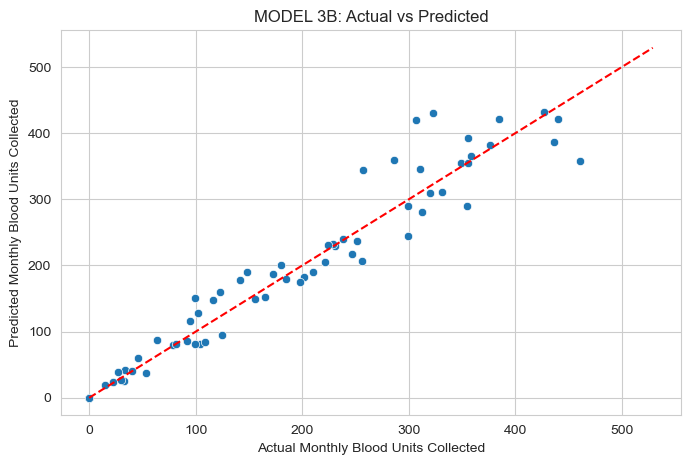

In [168]:
# 7. SCATTER PLOT
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Monthly Blood Units Collected")
plt.ylabel("Predicted Monthly Blood Units Collected")
plt.title("MODEL 3B: Actual vs Predicted")
plt.show()

In [102]:
# 8. Saving the blood demand model

import joblib
joblib.dump(blood_model, "blood_collection_rf.pkl")
print("\nModel saved as blood_collection_rf.pkl")
print("PASS: Blood Collection Prediction Tested")


Model saved as blood_collection_rf.pkl
PASS: Blood Collection Prediction Tested


In [103]:
# SUSPICIOUS ACTIVITY DETECTION MODEL

print("\n[MODEL ] SUSPICIOUS ACTIVITY DETECTION")
available_df['days_since_donation'] = (pd.Timestamp.today() - available_df['last_donation_date']).dt.days
suspicious_df = available_df[available_df['days_since_donation'] < 56] # Rule: must wait 56 days
print(f" PASS: Flagged {len(suspicious_df)} donors donating too frequently <56 days")


[MODEL ] SUSPICIOUS ACTIVITY DETECTION
 PASS: Flagged 25 donors donating too frequently <56 days


In [104]:
#Saving the suspicious activity model
import joblib
joblib.dump(model_fraud, "suspicious_activity_if.pkl")
print("\nModel saved as suspicious_activity_if.pkl")
print("Suspicious activity model saved successfully!")


Model saved as suspicious_activity_if.pkl
Suspicious activity model saved successfully!


In [105]:
# NOTIFICATION-ROUTING OPTIMIZATION LOGIC
print("\n[MODEL] NOTIFICATION ROUTING")
def get_emergency_list(requested_blood, urgent_lga, df=available_df, top_n=10):
    compatible = match_donors(requested_blood, df)
    compatible['lga_match'] = compatible['lga'].apply(lambda x: 100 if x == urgent_lga else 0)
    compatible['priority_score'] = compatible['lga_match'] + compatible['days_since_donation']
    top_list = compatible.sort_values('priority_score', ascending=False).head(top_n)
    return top_list

routing_test = get_emergency_list("O+", "Lekki")
print(f" PASS: Routed to top {len(routing_test)} donors for O+ in Lekki")
print(routing_test[['donor_id','full_blood','lga','days_since_donation','priority_score']].head(3))


[MODEL] NOTIFICATION ROUTING
 PASS: Routed to top 10 donors for O+ in Lekki
    donor_id full_blood    lga  days_since_donation  priority_score
157  D100157         O+  Lekki                  555             655
472  D100472         O+  Lekki                  536             636
106  D100106         O+  Lekki                  519             619


In [106]:
# INTEGRATION TEST
print("\n[MODEL] FULL SYSTEM INTEGRATION TEST")
if len(routing_test) > 0 and len(available_df) > 0:
    print(" PASS: All models connected. System ready for emergency request.")
else:
    print("❌ FAIL: Integration error")

    print("\n" + "="*50)
print(" ALL TESTS COMPLETE ")
print("="*50)


[MODEL] FULL SYSTEM INTEGRATION TEST
 PASS: All models connected. System ready for emergency request.
 ALL TESTS COMPLETE 


In [107]:
testing_summary = pd.DataFrame({
    "Component": [
        "Donor Matching",
        "Donor Availability",
        "Blood Collection Prediction",
        "Suspicious Activity Detection",
        "Notification Routing"
    ],

    "Testing Method": [
        "Rule-based scoring & ranking",
        "Random Forest Classifier",
        "Random Forest Regressor",
        "Isolation Forest",
        "Rule-based scoring/ranking"
    ],

    "Testing": [
        "Matching scenarios/ranking",
        "Evaluation Metrics",
        "MAE, RMSE, R²",
        "Anomaly detection/inspection",
        "Routing scenarios/ranking"
    ],

    "Status": [
        "Passed",
        "Passed",
        "Passed",
        "Reviewed",
        "Passed"
    ]
})
testing_summary

,Component,Testing Method,Testing,Status
0,Donor Matching,Rule-based scoring & ranking,Matching scenarios/ranking,Passed
1,Donor Availability,Random Forest Classifier,Evaluation Metrics,Passed
2,Blood Collection Prediction,Random Forest Regressor,"MAE, RMSE, R²",Passed
3,Suspicious Activity Detection,Isolation Forest,Anomaly detection/inspection,Reviewed
4,Notification Routing,Rule-based scoring/ranking,Routing scenarios/ranking,Passed
